In [4]:
## Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## Importation du fichier csv Otlis
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset (2).csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [5]:
## Chargement des fichiers csv et transformtation en Dataframe

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

# Exploration des données du dataset Orders

In [11]:
## Lecture des premières lignes
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [25]:
## Informations détaillée des colonnes de Orders

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [30]:
## Détection des valeurs manquantes
valeurs_manquantes = (orders.isnull().sum() / len(orders) * 100).round(2)
print(valeurs_manquantes[valeurs_manquantes > 0])

order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
dtype: float64


Commentaire : Pour un dataset e-commerce, ces valeurs manquantes ne consttituent pas des erreurs.
- order_approved_at : il peut avoir des commandes qui n'ont pas été approuvées
- order_delivered_carrier_date : il s'agit des commandes qui n'ont pas encore été récupérées par le transporteur
- order_delivered_customer_date : il s'agit des commandes pas encore livrées au client

In [29]:
## On se concentrera sur les commandes dont le statut est livrée

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print("Commandes livrées :" + str(len(orders_delivered)))

Commandes livrées :96478


In [31]:
## Conversion des colonnes dates en datetime

cols_dates = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in cols_dates:
    orders_delivered[col] = pd.to_datetime(orders_delivered[col])
print(orders_delivered[cols_dates].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


# Analyse des ventes dans le temps

In [33]:
## extraction du mois dans la colonne date d'achat
orders_delivered['mois'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

## nombre de commandes par mois avec groupby
commandes_par_mois = (orders_delivered.groupby('mois').size().reset_index(name='nb_commandes'))
print(commandes_par_mois.head(10))

      mois  nb_commandes
0  2016-09             1
1  2016-10           265
2  2016-12             1
3  2017-01           750
4  2017-02          1653
5  2017-03          2546
6  2017-04          2303
7  2017-05          3546
8  2017-06          3135
9  2017-07          3872


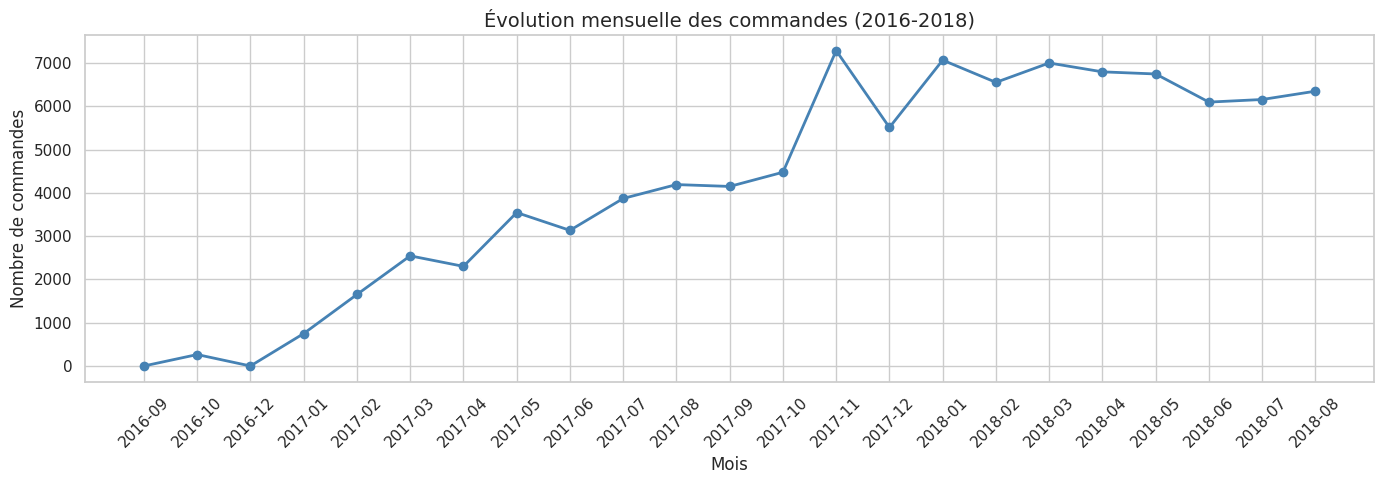

In [37]:
## Visualisation des commandes par mois

commandes_par_mois['mois_str'] = commandes_par_mois['mois'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(commandes_par_mois['mois_str'], commandes_par_mois['nb_commandes'], marker='o',        # un point à chaque mois
    linewidth=2, color='steelblue')

plt.title('Évolution mensuelle des commandes (2016-2018)', fontsize=14)
plt.xlabel('Mois')
plt.ylabel('Nombre de commandes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Analyse de la satisfaction client

/tmp/ipykernel_1229/349204870.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews,


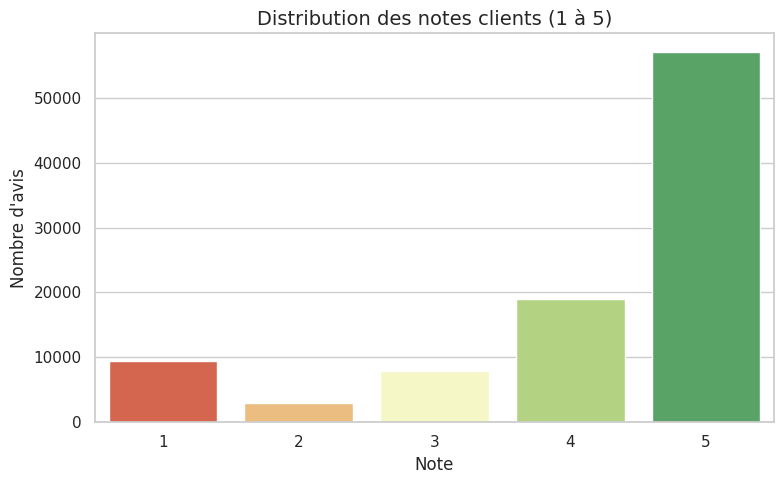

In [38]:
# Fusion des tables Orders et avis
df_reviews = orders_delivered.merge(
    reviews[['order_id', 'review_score']], on='order_id', how='inner')

# Graphique
plt.figure(figsize=(8, 5))

sns.countplot(data=df_reviews,
    x='review_score',
    palette='RdYlGn',
    order=[1, 2, 3, 4, 5])
plt.title('Distribution des notes clients (1 à 5)', fontsize=14)
plt.xlabel('Note')
plt.ylabel('Nombre d\'avis')
plt.tight_layout()
plt.show()

# Analyse du lien entre la satisfaction et le délai de livraison

In [47]:
# Calcul du délai entre achat et livraison
df_reviews['delai_livraison_jours'] = (df_reviews['order_delivered_customer_date'] -
    df_reviews['order_purchase_timestamp']).dt.days

df_reviews['retard_jours'] = (df_reviews['order_delivered_customer_date'] -
    df_reviews['order_estimated_delivery_date']).dt.days

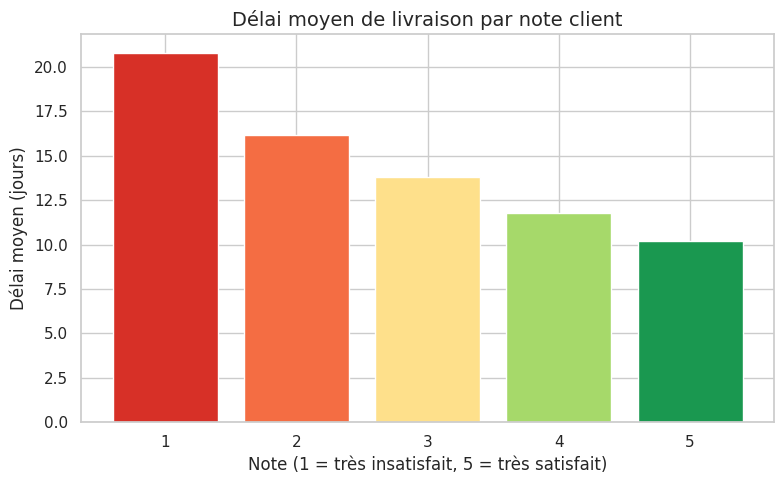

In [55]:
# Calcul du délai moyen par note
delai_par_note = (df_reviews.groupby('review_score')['delai_livraison_jours'].mean().round(1).reset_index())
delai_par_note.columns = ['note', 'delai_moyen']

# Graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(
   delai_par_note['note'],
    delai_par_note['delai_moyen'],
    color=['#d73027', '#f46d43', '#fee08b', '#a6d96a', '#1a9850'] )
plt.title('Délai moyen de livraison par note client', fontsize=14)
plt.xlabel('Note (1 = très insatisfait, 5 = très satisfait)')
plt.ylabel('Délai moyen (jours)')
plt.tight_layout()
plt.show()

Commentaire : On observe qu'il y'a bien un lien entre le délai de livraison et les avis des clients. Plus le délai est long et moins le client est satisfait